# R&D-8. Множественное тестирование (OR-регион) — ноутбук для внутреннего контура

**Самодостаточный ноутбук.** Весь код пакета `rnd_reports.multiple_testing` вшит ниже в ячейки — импортов `rnd_reports` нет, файл переносится во внутренний контур одним куском и запускается там, где есть только `numpy / pandas / scipy / statsmodels / matplotlib`.

**Как использовать во внутреннем контуре:**
1. В ячейке-конфиге укажи `INPUT_CSV` — путь к своей таблице (контракт `id, treatment, target_1..n`).
2. Ячейку-генератор синтетики (помечена ⚠️) **не запускай** — она нужна только для проверки запускаемости ноутбука в репозитории.
3. Прогони остальные ячейки: single-table сравнение методов множественного тестирования на одной таблице.

`true_effects` известны только для синтетики; на реальных данных оценка power/FDR пропускается. Сравнение operating characteristics (Monte-Carlo по многим датасетам) живёт в исследовательском `notebook.ipynb`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Sequence, Tuple
from scipy import stats
from statsmodels.stats.multitest import multipletests

## Библиотека (вшита из `rnd_reports.multiple_testing`)

Пять модулей пакета подряд, в порядке зависимостей: контракт и элементарные Welch-тесты (`elementary`), методы коррекции (`methods`), генератор синтетики (`synthetic`), single-table сравнение (`pipeline`), Monte-Carlo (`simulation`). Это идентичный коду репозитория слой — при желании можно свернуть ячейки и сразу перейти к демонстрации.

In [2]:
# === Вшито из rnd_reports.multiple_testing/elementary.py ===

def infer_target_columns(
    df: pd.DataFrame,
    id_col: str = "id",
    treatment_col: str = "treatment",
    target_cols: Optional[List[str]] = None,
) -> List[str]:
    """Определить target-колонки по контракту таблицы (всё, кроме id/treatment)."""
    if target_cols is not None:
        missing = [c for c in target_cols if c not in df.columns]
        if missing:
            raise ValueError(f"В таблице нет target-колонок: {missing}")
        return list(target_cols)

    excluded = {id_col, treatment_col}
    inferred = [c for c in df.columns if c not in excluded]
    if not inferred:
        raise ValueError("Не найдено ни одной target-колонки")
    return inferred


def validate_input_table(
    df: pd.DataFrame,
    id_col: str = "id",
    treatment_col: str = "treatment",
    target_cols: Optional[List[str]] = None,
) -> List[str]:
    """Проверить минимальные требования к таблице и вернуть список target-колонок."""
    for col in (id_col, treatment_col):
        if col not in df.columns:
            raise ValueError(f"Нет обязательной колонки: {col}")

    targets = infer_target_columns(df, id_col=id_col, treatment_col=treatment_col, target_cols=target_cols)

    unique_treatments = set(pd.Series(df[treatment_col]).dropna().unique())
    if not unique_treatments.issubset({0, 1}):
        raise ValueError(f"{treatment_col} должен содержать только 0/1; найдено {sorted(unique_treatments)}")

    non_numeric = [c for c in targets if not pd.api.types.is_numeric_dtype(df[c])]
    if non_numeric:
        raise ValueError(f"Все target-колонки должны быть числовыми; не числовые: {non_numeric}")

    group_sizes = df[treatment_col].value_counts(dropna=False).to_dict()
    if 0 not in group_sizes or 1 not in group_sizes:
        raise ValueError("В таблице должны присутствовать обе группы: control=0 и treatment=1")

    return targets


def compute_elementary_tests(
    df: pd.DataFrame,
    target_cols: List[str],
    treatment_col: str = "treatment",
    alpha: float = 0.05,
) -> pd.DataFrame:
    """Welch t-test (treatment − control) по каждой target-метрике через scipy.

    Возвращает таблицу с колонками ``target, effect, std_error, t_stat, p_value,
    ci_low, ci_high`` (отсортированной как пришли target-колонки).
    """
    mask_t = df[treatment_col].to_numpy() == 1
    rows = []
    for target in target_cols:
        x1 = df.loc[mask_t, target].to_numpy(dtype=float)
        x0 = df.loc[~mask_t, target].to_numpy(dtype=float)
        # Готовый Welch t-test scipy; nan_policy='omit' выбрасывает пропуски.
        res = stats.ttest_ind(x1, x0, equal_var=False, nan_policy="omit")
        ci = res.confidence_interval(confidence_level=1 - alpha)
        effect = float(np.nanmean(x1) - np.nanmean(x0))
        t_stat = float(res.statistic)
        # std_error восстанавливаем из определения t = effect / se.
        se = float(effect / t_stat) if np.isfinite(t_stat) and t_stat != 0.0 else float("nan")
        rows.append(
            {
                "target": target,
                "effect": effect,
                "std_error": se,
                "t_stat": t_stat,
                "p_value": float(res.pvalue),
                "ci_low": float(ci.low),
                "ci_high": float(ci.high),
            }
        )
    return pd.DataFrame(rows)


def compute_vectorized_t_stats(y: np.ndarray, treatment: np.ndarray) -> np.ndarray:
    """Векторные Welch t-статистики по всем колонкам ``y`` для бинарного ``treatment``.

    Используется внутри перестановочного цикла (Westfall–Young / Romano–Wolf): тысячи
    перестановок × n метрик, поэтому поячейный вызов scipy в цикле слишком медленный —
    здесь это осознанная векторная оптимизация той же Welch-статистики.
    """
    treatment = np.asarray(treatment).astype(int)
    mask_t = treatment == 1
    y_t = y[mask_t]
    y_c = y[~mask_t]
    n_t, n_c = y_t.shape[0], y_c.shape[0]
    if n_t < 2 or n_c < 2:
        raise ValueError("В обеих группах должно быть не меньше двух наблюдений")

    mean_t = np.nanmean(y_t, axis=0)
    mean_c = np.nanmean(y_c, axis=0)
    var_t = np.nanvar(y_t, axis=0, ddof=1)
    var_c = np.nanvar(y_c, axis=0, ddof=1)
    se = np.sqrt(var_t / n_t + var_c / n_c)
    with np.errstate(divide="ignore", invalid="ignore"):
        t = (mean_t - mean_c) / se
    return np.where(np.isfinite(t), t, 0.0)

In [3]:
# === Вшито из rnd_reports.multiple_testing/methods.py ===

# Порядок методов в таблицах/графиках: FWER-семейство, затем FDR-ориентир.
METHOD_NAMES: List[str] = [
    "bonferroni",
    "holm",
    "westfall_young",
    "romano_wolf",
    "benjamini_hochberg",
]

# Какой метод какой ошибкой управляет — для отчётности и группировки.
METHOD_ERROR: Dict[str, str] = {
    "bonferroni": "FWER",
    "holm": "FWER",
    "westfall_young": "FWER",
    "romano_wolf": "FWER",
    "benjamini_hochberg": "FDR",
}


def _build_permutation_t_statistics(
    df: pd.DataFrame,
    target_cols: List[str],
    treatment_col: str,
    n_resamples: int,
    random_state: int,
) -> Tuple[np.ndarray, np.ndarray]:
    """Наблюдаемые и перестановочные t-статистики семейства.

    Возвращает ``(t_obs[n_targets], t_perm[n_resamples, n_targets])``. Перестановка
    treatment-лейблов — естественная нулевая модель для рандомизированного эксперимента
    (совместное распределение статистик семейства сохраняет корреляцию метрик).
    """
    rng = np.random.default_rng(random_state)
    y = df[target_cols].to_numpy(dtype=float)
    treatment = df[treatment_col].to_numpy(dtype=int)

    t_obs = compute_vectorized_t_stats(y, treatment)
    t_perm = np.empty((n_resamples, len(target_cols)), dtype=float)
    for b in range(n_resamples):
        t_perm[b] = compute_vectorized_t_stats(y, rng.permutation(treatment))
    return t_obs, t_perm


def westfall_young_maxT_adjusted_pvalues(t_obs: np.ndarray, t_perm: np.ndarray) -> np.ndarray:
    """Single-step Westfall–Young maxT adjusted p-values (двусторонние тесты).

    Калибруется по распределению максимума |t| по всему семейству — отсюда контроль
    FWER с учётом зависимости метрик. Сглаживание ``+1`` исключает нулевые p-value при
    конечном числе перестановок.
    """
    abs_obs = np.abs(np.asarray(t_obs, dtype=float))
    abs_perm = np.abs(np.asarray(t_perm, dtype=float))
    max_perm = np.max(abs_perm, axis=1)
    p_adj = (1 + np.sum(max_perm[None, :] >= abs_obs[:, None], axis=1)) / (len(max_perm) + 1)
    return np.minimum(p_adj, 1.0)


def romano_wolf_stepdown_adjusted_pvalues(t_obs: np.ndarray, t_perm: np.ndarray) -> np.ndarray:
    """Romano–Wolf stepdown adjusted p-values (двусторонние тесты).

    Гипотезы сортируются по убыванию |t|. На шаге k референс — максимум |T| по ещё
    активному (сужающемуся) множеству гипотез, поэтому процедура мощнее single-step
    Westfall–Young при сохранении контроля FWER. Готового решения в scipy нет.
    """
    abs_obs = np.abs(np.asarray(t_obs, dtype=float))
    abs_perm = np.abs(np.asarray(t_perm, dtype=float))
    n_hyp = abs_obs.size
    n_perm = abs_perm.shape[0]

    order = np.argsort(-abs_obs)  # самый сильный сигнал — первым
    raw_step_p = np.empty(n_hyp, dtype=float)
    for k, hyp_idx in enumerate(order):
        active = order[k:]
        max_active_perm = np.max(abs_perm[:, active], axis=1)
        raw_step_p[k] = (1 + np.sum(max_active_perm >= abs_obs[hyp_idx])) / (n_perm + 1)

    # Монотонность вдоль stepdown-порядка.
    adj_ordered = np.maximum.accumulate(raw_step_p)
    p_adj = np.empty(n_hyp, dtype=float)
    p_adj[order] = np.minimum(adj_ordered, 1.0)
    return p_adj


def add_corrections(
    tests_df: pd.DataFrame,
    df: pd.DataFrame,
    target_cols: List[str],
    treatment_col: str = "treatment",
    alpha: float = 0.05,
    n_resamples: int = 1000,
    random_state: int = 42,
) -> pd.DataFrame:
    """Добавить adjusted p-value и reject-флаги всех методов к таблице элементарных тестов.

    Возвращает копию ``tests_df`` с колонками ``p_adj_<method>`` и ``reject_<method>``
    для каждого имени из :data:`METHOD_NAMES`.
    """
    out = tests_df.copy()
    p = out["p_value"].to_numpy(dtype=float)

    # p-value-only: Bonferroni / Holm — готовый statsmodels.multipletests.
    for name, sm_method in (("bonferroni", "bonferroni"), ("holm", "holm")):
        _, p_adj, _, _ = multipletests(p, alpha=alpha, method=sm_method)
        out[f"p_adj_{name}"] = p_adj

    # FDR-ориентир: Benjamini–Hochberg — готовый scipy.stats.false_discovery_control.
    out["p_adj_benjamini_hochberg"] = stats.false_discovery_control(p, method="bh")

    # Resampling-методы на общей перестановочной матрице t-статистик.
    t_obs, t_perm = _build_permutation_t_statistics(
        df, target_cols, treatment_col=treatment_col, n_resamples=n_resamples, random_state=random_state
    )
    # Выровнять порядок t_obs (как target_cols) с порядком строк tests_df.
    pos = {t: i for i, t in enumerate(target_cols)}
    idx = out["target"].map(pos).to_numpy()
    out["p_adj_westfall_young"] = westfall_young_maxT_adjusted_pvalues(t_obs, t_perm)[idx]
    out["p_adj_romano_wolf"] = romano_wolf_stepdown_adjusted_pvalues(t_obs, t_perm)[idx]

    for name in METHOD_NAMES:
        out[f"reject_{name}"] = out[f"p_adj_{name}"].to_numpy(dtype=float) <= alpha
    return out


def reject_columns() -> Dict[str, str]:
    """{имя метода → колонка reject_<method>} в каноническом порядке."""
    return {name: f"reject_{name}" for name in METHOD_NAMES}


def p_adj_columns() -> Dict[str, str]:
    """{имя метода → колонка p_adj_<method>} в каноническом порядке."""
    return {name: f"p_adj_{name}" for name in METHOD_NAMES}

In [4]:
# === Вшито из rnd_reports.multiple_testing/synthetic.py ===

def make_equicorrelation_cov(n_targets: int, rho: float, variances: Optional[np.ndarray] = None) -> np.ndarray:
    """Equicorrelation-ковариация с опциональными гетерогенными дисперсиями."""
    if not (-1 / max(n_targets - 1, 1) < rho < 1):
        raise ValueError("rho вне допустимого диапазона положительной определённости матрицы")
    corr = np.full((n_targets, n_targets), rho, dtype=float)
    np.fill_diagonal(corr, 1.0)
    if variances is None:
        variances = np.ones(n_targets)
    std = np.sqrt(np.asarray(variances, dtype=float))
    return corr * np.outer(std, std)


def make_ab_table(
    n: int = 5_000,
    n_targets: int = 15,
    rho: float = 0.45,
    n_true: int = 3,
    effect: float = 0.10,
    treatment_share: float = 0.5,
    seed: int = 42,
) -> Tuple[pd.DataFrame, Dict[str, float]]:
    """Синтетическая A/B-таблица ``id, treatment, target_1..n`` с известной правдой.

    Параметры:
        n: число юнитов;
        n_targets: число target-метрик (гипотез);
        rho: попарная корреляция метрик (ключ к различию методов);
        n_true: сколько метрик имеют ненулевой истинный эффект (первые ``n_true``);
        effect: величина аддитивного эффекта у истинно-ненулевых метрик;
        treatment_share: доля treatment-группы;
        seed: фиксированный seed.

    Возвращает ``(df, true_effects)``, где ``true_effects[target]`` — истинный эффект
    (0 для нулевых гипотез).
    """
    if not 0 <= n_true <= n_targets:
        raise ValueError("n_true должен быть в диапазоне [0, n_targets]")
    rng = np.random.default_rng(seed)
    target_cols = [f"target_{i}" for i in range(1, n_targets + 1)]

    true_effects = {col: 0.0 for col in target_cols}
    for col in target_cols[:n_true]:
        true_effects[col] = float(effect)

    treatment = rng.binomial(1, treatment_share, size=n)
    # Небольшая неоднородность дисперсий приближает пример к реальным метрикам.
    variances = np.linspace(0.8, 1.4, n_targets)
    cov = make_equicorrelation_cov(n_targets=n_targets, rho=rho, variances=variances)

    base = stats.multivariate_normal.rvs(mean=np.zeros(n_targets), cov=cov, size=n, random_state=rng)
    base = np.atleast_2d(base).reshape(n, n_targets)
    effects = np.array([true_effects[col] for col in target_cols])
    y = base + treatment[:, None] * effects[None, :]

    df = pd.DataFrame(y, columns=target_cols)
    df.insert(0, "treatment", treatment.astype(int))
    df.insert(0, "id", np.arange(1, n + 1))
    return df, true_effects

In [5]:
# === Вшито из rnd_reports.multiple_testing/pipeline.py ===

@dataclass
class ComparisonResult:
    """Результат сравнения методов на одной таблице."""

    table: pd.DataFrame              # target × (effect, p_value, p_adj_*, reject_*)
    method_summary: pd.DataFrame     # method × (error, n_rejected)
    truth_evaluation: Optional[pd.DataFrame]  # синтетика: method × (TP/FP/FDR/power)
    pvalue_profile: pd.DataFrame     # method × (mean_p_adj_signal/null, conservativeness_gap)
    target_cols: List[str]


def summarize_rejections(table: pd.DataFrame) -> pd.DataFrame:
    """Сводка «сколько target-метрик отвергнуто каждым методом»."""
    rows = []
    for name, col in reject_columns().items():
        rows.append(
            {
                "method": name,
                "error_control": METHOD_ERROR[name],
                "n_rejected": int(table[col].sum()),
            }
        )
    return pd.DataFrame(rows)


def evaluate_against_truth(
    table: pd.DataFrame,
    true_effects: Dict[str, float],
    effect_tol: float = 1e-12,
) -> pd.DataFrame:
    """Оценка методов против известной правды: TP/FP, realized FDR, power, FWER-событие."""
    truth = table["target"].map(lambda t: abs(float(true_effects.get(t, 0.0))) > effect_tol).to_numpy()
    n_non_null = int(truth.sum())

    rows = []
    for name, col in reject_columns().items():
        reject = table[col].to_numpy(dtype=bool)
        tp = int(np.sum(reject & truth))
        fp = int(np.sum(reject & ~truth))
        discoveries = int(np.sum(reject))
        rows.append(
            {
                "method": name,
                "error_control": METHOD_ERROR[name],
                "true_positives": tp,
                "false_positives": fp,
                "realized_fdr": fp / discoveries if discoveries > 0 else 0.0,
                "power": tp / n_non_null if n_non_null > 0 else np.nan,
                "fwer_event": bool(fp >= 1),
            }
        )
    return pd.DataFrame(rows)


def summarize_pvalue_profile(
    table: pd.DataFrame,
    true_effects: Optional[Dict[str, float]] = None,
    effect_tol: float = 1e-12,
) -> pd.DataFrame:
    """Скалярные сводки методов «через p-values».

    По каждому методу из :data:`METHOD_NAMES` считает:

    - ``mean_p_adj_signal`` — средний adjusted p-value по истинно-ненулевым target
      (сила детекции; NaN, если правда неизвестна или нет ненулевых эффектов);
    - ``mean_p_adj_null`` — средний adjusted p-value по нулевым target (калибровка;
      NaN без правды);
    - ``conservativeness_gap`` — среднее ``p_adj - p_value`` по всем target (инфляция
      над raw p-value; считается всегда, работает и на реальной таблице).

    Колонка ``error_control`` (FWER/FDR) намеренно сохранена: значения FWER-методов
    сравнимы между собой напрямую, а Benjamini–Hochberg — q-value «другой валюты»
    ошибки, поэтому строки FWER и FDR читаются раздельно, а не пулятся.
    """
    raw = table["p_value"].to_numpy(dtype=float)
    if true_effects is not None:
        truth = table["target"].map(
            lambda t: abs(float(true_effects.get(t, 0.0))) > effect_tol
        ).to_numpy()
    else:
        truth = None

    rows = []
    for name, col in p_adj_columns().items():
        p_adj = table[col].to_numpy(dtype=float)
        if truth is not None:
            signal = p_adj[truth]
            null = p_adj[~truth]
            mean_signal = float(np.mean(signal)) if signal.size else float("nan")
            mean_null = float(np.mean(null)) if null.size else float("nan")
        else:
            mean_signal = float("nan")
            mean_null = float("nan")
        rows.append(
            {
                "method": name,
                "error_control": METHOD_ERROR[name],
                "mean_p_adj_signal": mean_signal,
                "mean_p_adj_null": mean_null,
                "conservativeness_gap": float(np.mean(p_adj - raw)),
            }
        )
    return pd.DataFrame(rows)


def run_comparison(
    df: pd.DataFrame,
    id_col: str = "id",
    treatment_col: str = "treatment",
    target_cols: Optional[List[str]] = None,
    alpha: float = 0.05,
    n_resamples: int = 1000,
    random_state: int = 42,
    true_effects: Optional[Dict[str, float]] = None,
) -> ComparisonResult:
    """Прогнать все методы на одной таблице и собрать сравнительные артефакты."""
    targets = validate_input_table(df, id_col=id_col, treatment_col=treatment_col, target_cols=target_cols)
    tests = compute_elementary_tests(df, targets, treatment_col=treatment_col, alpha=alpha)
    corrected = add_corrections(
        tests, df, targets, treatment_col=treatment_col, alpha=alpha,
        n_resamples=n_resamples, random_state=random_state,
    )

    # Компактная таблица для просмотра глазами: статистики + adj p-value + reject-флаги.
    cols = ["target", "effect", "p_value"]
    for name in METHOD_NAMES:
        cols += [f"p_adj_{name}", f"reject_{name}"]
    table = corrected[cols].sort_values("p_value").reset_index(drop=True)

    method_summary = summarize_rejections(corrected)
    truth_eval = evaluate_against_truth(corrected, true_effects) if true_effects is not None else None
    pvalue_profile = summarize_pvalue_profile(corrected, true_effects)

    return ComparisonResult(
        table=table,
        method_summary=method_summary,
        truth_evaluation=truth_eval,
        pvalue_profile=pvalue_profile,
        target_cols=targets,
    )


# Реэкспорт для удобства витрины.

In [6]:
# === Вшито из rnd_reports.multiple_testing/simulation.py ===

@dataclass
class Scenario:
    """Один сценарий синтетики для симуляции."""

    rho: float
    n: int = 4_000
    n_targets: int = 15
    n_true: int = 3
    effect: float = 0.12
    treatment_share: float = 0.5
    extra: Dict[str, float] = field(default_factory=dict)

    def label(self) -> str:
        return f"rho={self.rho:g}"


def _single_run_rejections(
    df: pd.DataFrame,
    true_effects: Dict[str, float],
    alpha: float,
    n_resamples: int,
    seed: int,
) -> Dict[str, Dict[str, float]]:
    """Один прогон: по каждому методу вернуть fwer_event и долю найденных истинных."""
    targets = infer_target_columns(df)
    tests = compute_elementary_tests(df, targets, alpha=alpha)
    corrected = add_corrections(tests, df, targets, alpha=alpha, n_resamples=n_resamples, random_state=seed)

    truth = corrected["target"].map(lambda t: abs(float(true_effects.get(t, 0.0))) > 1e-12).to_numpy()
    n_non_null = int(truth.sum())

    out: Dict[str, Dict[str, float]] = {}
    for name, col in reject_columns().items():
        reject = corrected[col].to_numpy(dtype=bool)
        fp = int(np.sum(reject & ~truth))
        tp = int(np.sum(reject & truth))
        out[name] = {
            "fwer_event": float(fp >= 1),
            "power": tp / n_non_null if n_non_null > 0 else np.nan,
        }
    return out


def operating_characteristics(
    scenarios: Sequence[Scenario],
    n_sims: int = 200,
    alpha: float = 0.05,
    n_resamples: int = 500,
    base_seed: int = 0,
) -> pd.DataFrame:
    """Эмпирические FWER и power по методам для каждого сценария (усреднение по симуляциям).

    Возвращает tidy-таблицу со строками ``(scenario, rho, method, error_control, fwer, power,
    n_sims)``. Перестановки внутри каждого метода используют ``n_resamples`` (умеренно — это
    самый дорогой шаг), число симуляций ``n_sims`` задаёт точность оценок FWER/power.
    """
    rows = []
    for s_idx, scenario in enumerate(scenarios):
        agg = {name: {"fwer": [], "power": []} for name in METHOD_NAMES}
        for sim in range(n_sims):
            seed = base_seed + 1_000 * s_idx + sim
            df, true_effects = make_ab_table(
                n=scenario.n,
                n_targets=scenario.n_targets,
                rho=scenario.rho,
                n_true=scenario.n_true,
                effect=scenario.effect,
                treatment_share=scenario.treatment_share,
                seed=seed,
            )
            per_method = _single_run_rejections(df, true_effects, alpha, n_resamples, seed)
            for name in METHOD_NAMES:
                agg[name]["fwer"].append(per_method[name]["fwer_event"])
                agg[name]["power"].append(per_method[name]["power"])

        for name in METHOD_NAMES:
            powers = np.asarray(agg[name]["power"], dtype=float)
            # power неопределён, если в сценарии нет истинных эффектов (n_true=0).
            mean_power = float(np.nanmean(powers)) if np.any(np.isfinite(powers)) else float("nan")
            rows.append(
                {
                    "scenario": scenario.label(),
                    "rho": scenario.rho,
                    "method": name,
                    "error_control": METHOD_ERROR[name],
                    "fwer": float(np.mean(agg[name]["fwer"])),
                    "power": mean_power,
                    "n_sims": n_sims,
                }
            )
    return pd.DataFrame(rows)


def rho_grid(rhos: Sequence[float], **scenario_kwargs) -> List[Scenario]:
    """Удобный конструктор сетки сценариев, варьирующих только корреляцию ``rho``."""
    return [Scenario(rho=float(r), **scenario_kwargs) for r in rhos]

## 1. Данные: одна таблица из `INPUT_CSV`

Конфиг задаёт путь к таблице и параметры прогона. Ячейка-генератор синтезирует одну демонстрационную таблицу и пишет её в `INPUT_CSV` — её запускают только в репозитории для проверки запускаемости; во внутреннем контуре `INPUT_CSV` переключают на реальную таблицу, а генератор пропускают.

In [7]:
# --- Конфигурация прогона -------------------------------------------------------
# Контракт таблицы: колонки id, treatment, target_1..target_n.
# Каждая target-метрика — отдельная гипотеза о treatment effect; семейство образует OR-claim.
INPUT_CSV = "data/08_multiple_testing/sample.csv"  # во внутреннем контуре — путь к своей таблице
ALPHA = 0.05
SEED = 42
TRUE_EFFECTS = None  # реальные данные: правда неизвестна -> блок power/FDR пропускается

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
pd.set_option('display.precision', 4)

In [8]:
# +++ ЯЧЕЙКА-ГЕНЕРАТОР СИНТЕТИКИ +++
# +++ НЕ ЗАПУСКАТЬ ВО ВНУТРЕННЕМ КОНТУРЕ +++
# Синтез одной демонстрационной таблицы -> запись в INPUT_CSV. Нужна только для проверки
# запускаемости ноутбука в репозитории. Во внутреннем контуре используется реальная таблица,
# и эту ячейку пропускают (INPUT_CSV уже указывает на реальные данные).
from pathlib import Path

Path(INPUT_CSV).parent.mkdir(parents=True, exist_ok=True)
_df_syn, TRUE_EFFECTS = make_ab_table(n=4000, n_targets=15, rho=0.5, n_true=3, effect=0.11, seed=SEED)
_df_syn.to_csv(INPUT_CSV, index=False)
print(f'синтетическая таблица записана в {INPUT_CSV}: '
      f'{_df_syn.shape[0]} юнитов, {_df_syn.shape[1] - 2} метрик')

синтетическая таблица записана в data/08_multiple_testing/sample.csv: 4000 юнитов, 15 метрик


In [9]:
# Загрузка таблицы. Во внутреннем контуре сюда приходит реальная таблица из INPUT_CSV.
df = pd.read_csv(INPUT_CSV)
print(f'таблица: {df.shape[0]} юнитов, {df.shape[1] - 2} target-метрик')
print('истинно ненулевые эффекты (только синтетика):',
      {k: v for k, v in (TRUE_EFFECTS or {}).items() if v})

таблица: 4000 юнитов, 15 target-метрик
истинно ненулевые эффекты (только синтетика): {'target_1': 0.11, 'target_2': 0.11, 'target_3': 0.11}


## 2. Single-table: решения методов на одной таблице

`run_comparison` считает элементарные Welch-тесты по каждой метрике и adjusted p-value всех методов. Эта вьюшка одинаково работает на синтетике и на своей реальной таблице; при известной правде добавляется оценка TP/FP/FDR/power.

Помимо reject-решений сравниваем методы **«через p-values»** скалярными сводками (`res.pvalue_profile`): средний adjusted-p на истинно-ненулевых метриках (`mean_p_adj_signal` — сила детекции), на нулевых (`mean_p_adj_null` — калибровка) и `conservativeness_gap` = среднее `p_adj − p_raw` (инфляция над raw, считается и на реальных данных). Значения FWER-методов сравнимы напрямую; Benjamini–Hochberg — q-value «другой валюты» ошибки (FDR), его строку читаем отдельно.

In [10]:
res = run_comparison(df, true_effects=TRUE_EFFECTS, alpha=ALPHA, n_resamples=1000, random_state=SEED)

print('=== Сравнительная таблица: adjusted p-value по методам (топ по силе сигнала) ===')
show = ['target', 'effect', 'p_value'] + [f'p_adj_{m}' for m in METHOD_NAMES]
print(res.table[show].head(8).to_string(index=False))

print('\n=== Сколько target-метрик отвергнул каждый метод ===')
print(res.method_summary.to_string(index=False))

if res.truth_evaluation is not None:
    print('\n=== Оценка против известной правды (только синтетика) ===')
    print(res.truth_evaluation.to_string(index=False))

print('\n=== Скалярные сводки «через p-values»: детекция / калибровка / консервативность ===')
print(res.pvalue_profile.to_string(index=False))

=== Сравнительная таблица: adjusted p-value по методам (топ по силе сигнала) ===
   target  effect    p_value  p_adj_bonferroni  p_adj_holm  p_adj_westfall_young  p_adj_romano_wolf  p_adj_benjamini_hochberg
 target_3  0.1539 2.7379e-07        4.1068e-06  4.1068e-06                 0.001              0.001                4.1068e-06
 target_2  0.1344 7.8060e-06        1.1709e-04  1.0928e-04                 0.001              0.001                5.2493e-05
 target_1  0.1243 1.0499e-05        1.5748e-04  1.3648e-04                 0.001              0.001                5.2493e-05
target_13  0.0249 4.8875e-01        1.0000e+00  1.0000e+00                 0.999              0.997                9.6831e-01
target_12  0.0232 5.1921e-01        1.0000e+00  1.0000e+00                 1.000              0.997                9.6831e-01
target_14 -0.0218 5.6038e-01        1.0000e+00  1.0000e+00                 1.000              0.998                9.6831e-01
target_11 -0.0186 5.9844e-01        1

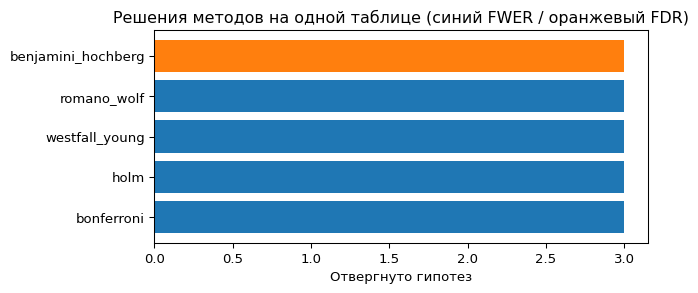

In [11]:
fig, ax = plt.subplots(figsize=(7, 3.2))
s = res.method_summary.sort_values('n_rejected')
colors = ['#1f77b4' if e == 'FWER' else '#ff7f0e' for e in s['error_control']]
ax.barh(s['method'], s['n_rejected'], color=colors)
ax.set_xlabel('Отвергнуто гипотез'); ax.set_title('Решения методов на одной таблице (синий FWER / оранжевый FDR)')
fig.tight_layout(); plt.show()

## 4. Выводы (single-table)

- На одной таблице методы дают согласованные решения по сильным сигналам; различие — на грани значимости, где Romano–Wolf и Westfall–Young менее консервативны при том же контроле FWER.
- Скалярные сводки «через p-values» (`pvalue_profile`) сравнивают методы и на реальных данных, где правда неизвестна: детекция (`mean_p_adj_signal`), калибровка (`mean_p_adj_null`), консервативность (`conservativeness_gap`).
- Benjamini–Hochberg (FDR) мощнее, но допускает больше ложных находок — компаратор для exploration, а не launch-процедура OR-claim.
- Эмпирический FWER/power по сетке корреляций (Monte-Carlo по многим датасетам) — в исследовательском `notebook.ipynb`; здесь фокус на одной таблице.